# Chicken-Wing-Index — a quantitative teardown 🔬
### Per-month HAC t-stats · Bonferroni · window-vs-rest spread + block-bootstrap CI · 12-month placebo · Jan-alpha-vs-SPY · timer race · sub-period split

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Super Bowl bump?: Busted](https://img.shields.io/badge/Super_Bowl_bump%3F-Busted-8b949e?style=flat-square)

The deep companion to [the notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test WING Super-Bowl seasonality on 131 months (11 Januaries) and find a data-snooped January, an off-thesis November that beats it, a negative game month, and a timer that only wins on Sharpe by de-risking into cash.

> ⚠️ Not investment advice. WING (price-only in practice — no dividend), SPY (total-return-ish) and the 13-week T-bill (^IRX) monthly, 2015-07 → 2026-05, 131 months (Yahoo Finance, daily closes resampled to month-end, grid asserted hole-free). Offline, every cell falls back to the synthetic NULL and banners the tape. Sources in [`docs/references.md`](../docs/references.md).
>
> 💡 The `💡 In plain words` notes translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (chicken_wing_index/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from chicken_wing_index import data, strategy as st

# Cache-first real tape; fall back to the synthetic NULL control OFFLINE and banner which tape we show.
try:
    from quantlab import repro
    d = repro.as_of(data.fetch_data())   # cache-first (examples/verify.py --fetch)
    if d.empty:
        raise RuntimeError("cache miss")
    TAPE = "REAL  (WING monthly, 2015-07..2026-05, 131 months, fp 5742cb7dc999)"
except Exception as e:
    d, _ = data.synthetic_world(superbowl_premium=0.0, seed=726)  # the NULL synthetic world
    TAPE = f"SYNTHETIC NULL control (offline fallback: {e}) -- NOT the real tape"
print("TAPE:", TAPE)
rf    = d["tbill"]
timer = st.superbowl_timer(d["wing"], tbill=rf)
net   = st.apply_costs(timer, n_trades_per_year=2, cost_bps_one_way=10)
bh    = st.buy_hold(d["wing"])
ms    = st.month_stats(d["wing"])
win   = st.superbowl_window_test(d["wing"])
alpha = st.window_alpha_vs_market(d["wing"], d["spy"])


TAPE: REAL  (WING monthly, 2015-07..2026-05, 131 months, fp 5742cb7dc999)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **None** | window−rest spread t = 1.62, 95% CI [−0.31%, +10.36%]; January is 1 of 12 snooped months, Bonferroni needs \|t\| ≈ 3 |
| Tradability | **Mirage** | timer Sharpe 0.63 vs buy-and-hold 0.57 — a de-risking illusion that forgoes >half of WING's 20.7% CAGR |
| Super-Bowl bump? | **Busted** | February (the game) is −2.01%; Jan-alpha-vs-SPY t = 2.00 on 11 pts, β ≈ 1 — half the ordinary January effect |

> 💡 In plain words: the most *fun* seasonal story on the bench leaves no robust statistical fingerprint, because a single lucky January among twelve months is exactly what selection manufactures.

## 1 · The claim, steelmanned

- **H₁:** at least one Super-Bowl-adjacent month (January run-up, or February the game) has a significantly positive mean return that survives multiple testing.
- **H₂:** the run-up window (January) has a significantly higher mean than every other month — Welch two-sample test.
- **H₃:** the window-minus-rest spread's block-bootstrap 95% CI excludes zero.
- **H₄ (placebo):** January ranks #1 among all twelve single-month bets (as the causal story requires).
- **H₅:** January's pop is WING-specific alpha, not the market's own January effect.
- **H₆:** the long-January calendar timer beats buy-and-hold (excess Sharpe), and it is stable across sub-periods.

## 2 · So what? — what rides on each

If H₁–H₆ hold, a fixed-month rule harvests a demand-driven premium with no forecasting. If they fail, the wing narrative is folklore: a genuinely huge but *already-priced* demand pulse, plus one lucky January we over-remember, on a stock that compounded at 20%/yr regardless.

## 3 · How we'd know — the protocol

One-sample t-stats (naive **and** Newey-West HAC — the latter flagged unreliable at n ≈ 11) for each of the 12 calendar months vs 0 (Bonferroni threshold |t| ≈ 3 for α = 0.05/12); a Welch two-sample test for the January window vs every other month; a circular block-bootstrap (12-month blocks) 95% CI on the spread; the 12-month **placebo** ranking; an OLS of January WING on same-month SPY to strip the January effect; and the calendar timer (long January, T-bill otherwise — calendar-known, **no execution lag**) vs buy-and-hold, Sharpe in **excess of the T-bill on both legs**, gross and net of 10 bp/leg, plus a 2016–2020 / 2021-on split.

## 4 · The teardown

### 4.1 Per-month t-stats, naive and HAC (H₁)

In [2]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'TAPE: {TAPE}\n')
print(f'{"Month":6s}  {"Mean":>8s}  {"t-naive":>8s}  {"t-HAC":>8s}  {"n":>4s}  Signal?')
for m in range(1,13):
    row = ms.loc[m]
    sig = '|t|>=3 (Bonferroni)' if abs(row['tstat'])>=3 else (
          '|t|>=2 (nominal only)' if abs(row['tstat'])>=2 else 'noise')
    print(f'{month_names[m-1]:6s}  {row["mean"]*100:+7.2f}%  {row["tstat"]:+8.2f}  '
          f'{row["tstat_hac"]:+8.2f}  {int(row["n"]):4d}  {sig}')

TAPE: REAL  (WING monthly, 2015-07..2026-05, 131 months, fp 5742cb7dc999)

Month       Mean   t-naive     t-HAC     n  Signal?
Jan       +7.20%     +2.52     +5.36    11  |t|>=2 (nominal only)
Feb       -2.01%     -0.58     -0.80    11  noise
Mar       -3.51%     -0.78     -0.81    11  noise
Apr       +9.39%     +1.83     +2.54    11  noise
May       +1.86%     +0.53     +0.61    11  noise
Jun       +6.02%     +2.25     +2.56    10  |t|>=2 (nominal only)
Jul       +8.58%     +1.25     +1.63    11  noise
Aug       +2.42%     +0.53     +0.50    11  noise
Sep       -3.49%     -1.00     -1.04    11  noise
Oct       -4.51%     -1.05     -1.14    11  noise
Nov       +9.97%     +2.70     +2.95    11  |t|>=2 (nominal only)
Dec       -1.29%     -0.49     -0.55    11  noise


> 💡 In plain words: three months (November, January, June) clear a *naive* |t| ≥ 2 — but the largest is **November**, entirely off-thesis, and none clears the Bonferroni bar for 12 tests (|t| ≈ 3). The HAC t looks huge for January (~5.4) but that is a small-sample artefact: with ~11 points the HAC long-run variance is meaningless. **H₁ not supported.**

### 4.2 January window vs the rest + block-bootstrap CI (H₂, H₃)

In [3]:
print(f'January run-up window: {win["window_mean"]*100:+.2f}%  n={win["n_window"]}')
print(f'Every other month:     {win["rest_mean"]*100:+.2f}%  n={win["n_rest"]}')
print(f'Window - rest spread:  {win["spread"]*100:+.2f}%  Welch t={win["tstat"]:.2f}')
ci = st.spread_bootstrap_ci(d['wing'], n_boot=5000, seed=726)
print(f'Block-bootstrap 95% CI on spread: [{ci["lo"]*100:.2f}%, {ci["hi"]*100:.2f}%]  '
      f'(point {ci["point"]*100:+.2f}%, n_boot={ci["n_boot"]})')
print('CI straddles 0:', ci['lo'] < 0 < ci['hi'])
feb = st.superbowl_window_test(d['wing'], window=[2])
print(f'\nFebruary (game month) vs rest: {feb["spread"]*100:+.2f}%  t={feb["tstat"]:.2f}  <- sell-the-news')

January run-up window: +7.20%  n=11
Every other month:     +2.10%  n=120
Window - rest spread:  +5.10%  Welch t=1.62


Block-bootstrap 95% CI on spread: [-0.31%, 10.36%]  (point +5.10%, n_boot=5000)
CI straddles 0: True

February (game month) vs rest: -4.95%  t=-1.33  <- sell-the-news


> 💡 In plain words: the Welch t is 1.62 and the bootstrap CI runs roughly −0.3% to +10.4% — it includes zero. And February, the actual Super Bowl, is *negative*. The thesis-level test fails. **H₂ and H₃ rejected.**

### 4.3 The 12-month placebo — is January special? (H₄)

In [4]:
pl = st.placebo_months(d['wing'], tbill=rf)
display(pl.assign(month=[month_names[int(m)-1] for m in pl.index])
          [['month','mean','tstat','sharpe']].round(3).reset_index(drop=True))
print(f"January's rank by Sharpe: #{list(pl.index).index(1)+1} of 12  (November is #1)")

,month,mean,tstat,sharpe
0,Nov,0.100,2.700,0.657
1,Jan,0.072,2.517,0.625
2,Jun,0.060,2.245,0.567
3,Apr,0.094,1.831,0.498
4,Jul,0.086,1.251,0.363
5,Aug,0.024,0.528,0.153
6,May,0.019,0.530,0.150
7,Dec,-0.013,-0.485,-0.170
8,Feb,-0.020,-0.575,-0.196
9,Mar,-0.035,-0.780,-0.252


January's rank by Sharpe: #2 of 12  (November is #1)


> 💡 In plain words: the causal story demands January at the top. Instead **November ranks #1** (Sharpe 0.66) with January #2 (0.63) and June #3. A 12-way search whose winner is an unrelated month is the textbook data-snooping signature (Sullivan-Timmermann-White). **H₄ rejected.**

### 4.4 Is it wings, or just the January effect? (H₅)

In [5]:
print(f'January WING alpha vs SPY: {alpha["alpha_m"]*100:+.2f}%/mo  t={alpha["t_alpha"]:.2f}  '
      f'beta={alpha["beta"]:.2f}  (n={alpha["n"]})')
print(f'Mean January WING excess of SPY: {alpha["mean_excess"]*100:+.2f}%')
spy_jan = d['spy'][pd.DatetimeIndex(d['spy'].index).month==1]
print(f"SPY's own average January: {spy_jan.mean()*100:+.2f}%  <- the January effect WING partly inherits")

January WING alpha vs SPY: +5.69%/mo  t=2.00  beta=1.03  (n=11)
Mean January WING excess of SPY: +5.73%
SPY's own average January: +1.47%  <- the January effect WING partly inherits


> 💡 In plain words: WING's January alpha over SPY is +5.7%/mo but its t is **exactly 2.00 on 11 points**, with beta ≈ 1 — it sits right on the significance line and would cross under with one weak January. And SPY's own January is positive, so part of WING's pop is the ordinary turn-of-year effect, not wings. Fragile, and partly confounded. **H₅ not supported.**

### 4.5 Calendar timer vs buy-and-hold, gross and net (H₆)

In [6]:
res = {
    'Super-Bowl timer (gross)': st.summary(timer, rf=rf),
    'timer (net 10bp/leg)':     st.summary(net,   rf=rf),
    'buy & hold WING':          st.summary(bh,    rf=rf),
}
display(pd.DataFrame(res).T[['cagr','sharpe','vol_ann','max_drawdown','n']].round(3))
print('Sharpe = excess of T-bill (^IRX), both legs, like-for-like; calendar-known rule, no lag')

,cagr,sharpe,vol_ann,max_drawdown,n
Super-Bowl timer (gross),0.090,0.625,0.114,-0.113,131.0
timer (net 10bp/leg),0.087,0.607,0.114,-0.115,131.0
buy & hold WING,0.207,0.574,0.491,-0.631,131.0


Sharpe = excess of T-bill (^IRX), both legs, like-for-like; calendar-known rule, no lag


> 💡 In plain words: the timer's Sharpe (0.63) edges buy-and-hold's (0.57) **only because it is in cash 11 months a year** — vol collapses from 0.49 to 0.11 and drawdown from −63% to −11%. It pays for that calm by forgoing >half the compound return (9.0% vs 20.7% CAGR). A risk-reduction that throws away return is not alpha. **H₆ rejected on the economics.**

### 4.6 Sub-period stability

In [7]:
d.index = pd.DatetimeIndex(d.index)
for lab, yr in [('2016-2020',(2016,2020)), ('2021-on',(2021,2030))]:
    sl = d[(d.index.year>=yr[0]) & (d.index.year<=yr[1])]
    r = st.superbowl_window_test(sl['wing'])
    print(f'{lab}: Jan={r["window_mean"]*100:+.2f}%  rest={r["rest_mean"]*100:+.2f}%  '
          f't={r["tstat"]:.2f}  n_Jan={r["n_window"]}')
print('\nNeither half clears |t|>=2 -> no stable seasonal law (and 5-6 Januaries is far too thin)')

2016-2020: Jan=+7.30%  rest=+3.69%  t=0.74  n_Jan=5
2021-on: Jan=+7.12%  rest=+1.10%  t=1.32  n_Jan=6

Neither half clears |t|>=2 -> no stable seasonal law (and 5-6 Januaries is far too thin)


> 💡 In plain words: the window spread is t = 0.74 (2016–2020) and t = 1.32 (2021-on) — never significant in either half. Five- and six-January sub-samples cannot certify a seasonal law.

### 4.7 The wholesale-wing-price proxy (labelled, cited, NOT tradable)

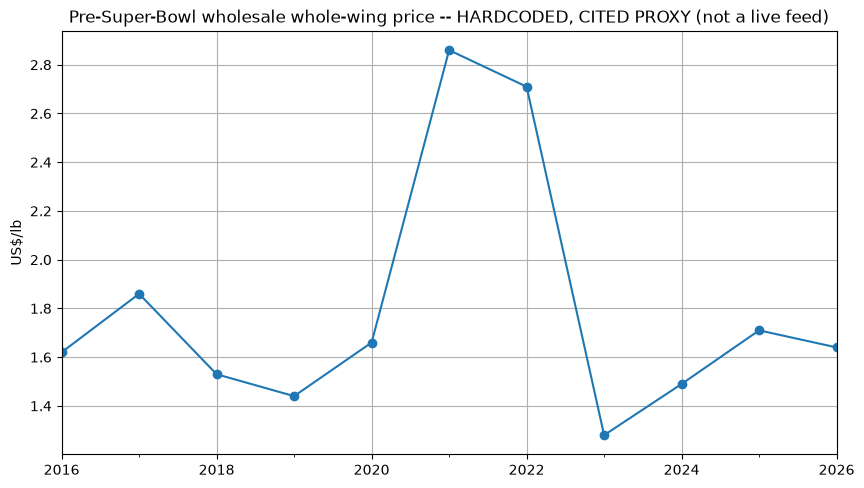

2021 record spike: $2.86/lb (+72% YoY, pandemic shortage)
2023 collapse:     $1.28/lb (-53% YoY)
Driven by avian-flu / supply shocks, not a Super-Bowl calendar -- and wings have no futures market.


In [8]:
wp = data.load_wing_price()
ax = wp.plot(marker='o', lw=1.5)
ax.set_ylabel('US$/lb'); ax.set_title('Pre-Super-Bowl wholesale whole-wing price -- HARDCODED, CITED PROXY (not a live feed)')
plt.show()
print(f"2021 record spike: ${wp.loc['2021-01-31']:.2f}/lb (+{data.wing_price_changes().loc['2021-01-31']:.0f}% YoY, pandemic shortage)")
print(f"2023 collapse:     ${wp.loc['2023-01-31']:.2f}/lb ({data.wing_price_changes().loc['2023-01-31']:.0f}% YoY)")
print('Driven by avian-flu / supply shocks, not a Super-Bowl calendar -- and wings have no futures market.')

> 💡 In plain words: even the *physical* wing price doesn't follow a clean Super-Bowl calendar — it exploded +72% into 2021 on a pandemic shortage and crashed −53% by 2023. This series is a **labelled proxy** reconstructed from public USDA/Urner-Barry/NCC reporting, not a live feed, and it isn't directly tradable — WING is the only tradable leg.

## 5 · The verdict

H₁ not supported (no month survives multiple testing). H₂/H₃ rejected (window spread t = 1.62, CI [−0.31%, +10.36%]; game month negative). H₄ rejected (November out-ranks January). H₅ not supported (Jan-alpha-vs-SPY t = 2.00 on 11 pts, β ≈ 1, half the January effect). H₆ rejected (timer wins on Sharpe only by de-risking into cash, forgoing >half the CAGR). → Signal `NONE`, Tradability `MIRAGE`, Super-Bowl bump `BUSTED`.

## 6 · Could you trade it?

No. There is no gross edge to defend — the break-even-cost question is moot. The long-January timer underperforms buy-and-hold WING by ~12%/yr in compound terms; its only "win" is lower variance bought by sitting in cash, and the month it picks isn't even the best. The billion-wing demand is real and already in the price of a wing; it is not a harvestable calendar in the stock.

## 7 · Going further

Forks: (a) a *daily* ±2-week event study around the actual game date rather than the calendar month; (b) test the post-game earnings same-store-sales print instead of the pre-game stock; (c) strip the January effect with a small-cap-growth factor rather than SPY; (d) a basket of "Super-Bowl stocks" (WING, PZZA, BROS…) to see if the effect is a chain artefact or a sector one. Companions: [307 Coffee-Seasonality](../../307-coffee-seasonality/), [358 Watch-Index](../../358-watch-index/).